### Aplicación kmeans

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd

# Cargar el archivo CSV subido
df = pd.read_csv("housing.csv")
# Eliminar columnas categóricas
df = df.drop(['ocean_proximity', 'total_bedrooms'], axis=1)
df = df.fillna(df.mean())


df = df[['median_house_value', 'latitude', 'longitude']]

####
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('cluster', KMeans(n_clusters=3))
])
pipeline.fit(df)





,steps,"[('scaler', ...), ('cluster', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [14]:
pipeline.named_steps['cluster'].labels_

array([2, 1, 1, ..., 1, 1, 1], dtype=int32)

/var/folders/q7/z6bgw1fj4vng6rs97g1chhz00000gn/T/ipykernel_63221/861241314.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Cluster")


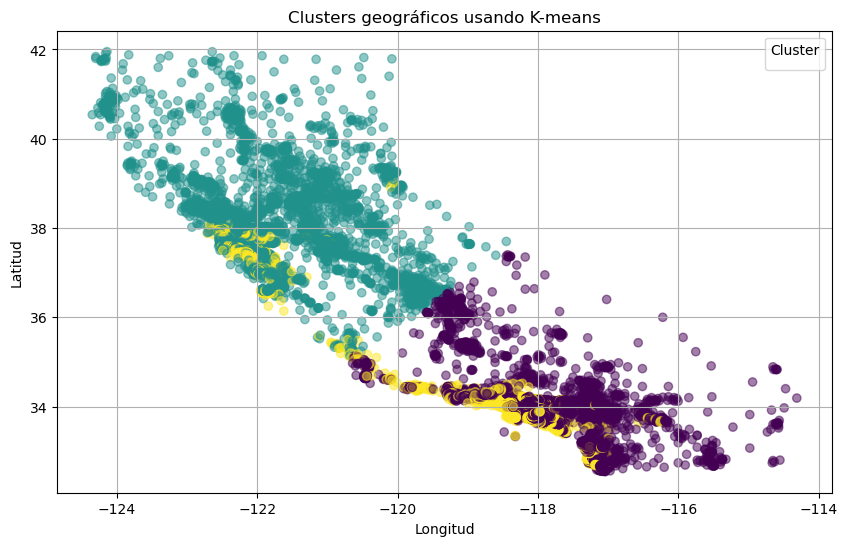

In [15]:
import seaborn as sns

# Obtener las etiquetas de cluster
labels = pipeline.named_steps['cluster'].labels_
df['cluster'] = labels


# Agregarlas al DataFrame original
# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(df.longitude, df.latitude, c=df.cluster, alpha=0.5)
plt.title("Clusters geográficos usando K-means")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()


### ¿Cuantos clusters escoger?

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Datos: ya filtrados en df
X = df[['median_house_value', 'latitude', 'longitude']]

inertias = []

import numpy as np
n_clusters = np.arange(2, 10)

for i in n_clusters:
    pipeline = Pipeline([
    ('scaler', StandardScaler()),
        # Poner cuantos clusters
    ('cluster', KMeans(n_clusters=i))
    ])
    pipeline.fit(X)
    inertias.append(pipeline['cluster'].inertia_)
    







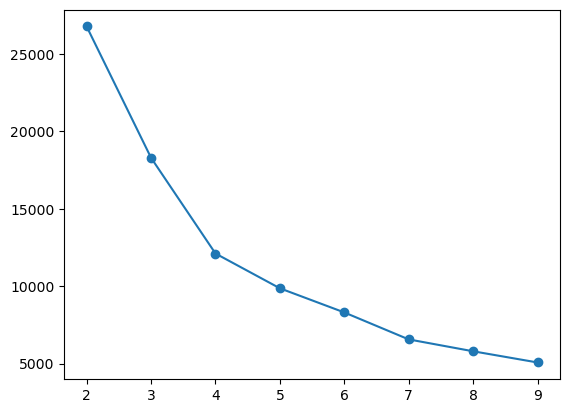

In [38]:
plt.plot(n_clusters, inertias, marker="o")